In [1]:
import typing as T
from typing import Dict, List, Tuple
import pickle
import json
import os
import pathlib
import pathlib as P
from pathlib import Path
import sys
import pandas as pd
import itertools as it
import functools as ft
import operator as opr
import collections as clt
import math
from math import pi
import re

In [2]:
import numpy as np
import pandas as pd
import sklearn.preprocessing as prep
from tqdm import tqdm
import scipy.sparse as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def ceil_to(x, step):
    return int(np.ceil(x / step)) * step

In [4]:
# def round_up_nice(x: int) -> int:
#     """
#     Round up a positive integer x to a 'nice' upper bound based on its magnitude.
#     Examples:
#         23 -> 24
#         145 -> 150
#         14874 -> 15000
#     """
#     if x <= 10:
#         return x if x == int(x) else math.ceil(x)

#     magnitude = 10 ** (len(str(int(x))) - 1)  # e.g. 145 -> 100, 14874 -> 10000
#     leading = x / magnitude                   # e.g. 1.45, 1.4874
#     step = magnitude / 10                     # finer step, e.g. 10, 1000

#     # round the leading number up to one decimal place and rescale
#     rounded = math.ceil(leading * 10) / 10
#     result = int(rounded * magnitude)
#     return result

In [5]:
def round_up_nice(x: int) -> int:
    if x <= 10:
        return math.ceil(x)
    magnitude = 10 ** (len(str(int(x))) - 1)
    rounded = math.ceil((x / magnitude) * 10) / 10
    return int(rounded * magnitude)

In [6]:
# def plot_degree_distribution(node_degree: dict,
#                              bins=10, log_scale=False, title=None,
#                              ):
#     """
#     Plot the degree distribution of a protein–protein interaction graph.

#     Parameters
#     ----------
#     node_degree : dict
#         {protein_id: degree} mapping.
#     bins : int or sequence
#         Histogram bins (default 50 or custom range list).
#     log_scale : bool
#         Whether to plot x/y axes in log scale.
#     title : str
#         Optional plot title.
#     """


#     # --- convert to numpy array ---
#     degree_values = np.array(list(node_degree.values()), dtype=int)

#     # --- compute histogram ---
#     max_degree = degree_values.max()
#     bins_ary = np.linspace(0, round_up_nice(max_degree), bins+1) if isinstance(bins, int) else bins
#     counts, bin_edges = np.histogram(degree_values, bins=bins_ary)

#     # --- plot ---
#     fig, ax = plt.subplots(figsize=(7, 5))
#     ax.bar(bin_edges[:-1], counts, width=np.diff(bin_edges),
#            align="edge", edgecolor="black", linewidth=0.5, color="skyblue")

#     ax.set_xlabel("Degree")
#     ax.set_ylabel("Number of proteins")
#     ax.set_title(title or "Protein Degree Distribution")

#     if log_scale:
#         ax.set_yscale("log")
#         ax.set_xscale("log")
#         ax.set_xlabel("Degree (log scale)")
#         ax.set_ylabel("Count (log scale)")

#     plt.tight_layout()
#     plt.show()

#     return counts, bin_edges

In [7]:
def plot_degree_distribution_broken(node_degree: dict,
                                   bins=10,
                                   title=None,
                                   bottom_ylim_ratio=1.2,
                                   gap_ratio=0.05,
                                   skip_ratio=0.9,
                                   saving_path=None):
    """
    Plot a broken-axis histogram:
      - Upper axis shows only degree=0 bar.
      - Lower axis shows all degrees (including 0, clipped).
      - Smooth visual connection between the two.
      - Annotates values on all bars.
    """
    # set direction in
    mpl.rcParams['xtick.direction'] = 'in'
    mpl.rcParams['ytick.direction'] = 'in'
    # set font family Arial
    mpl.rcParams['font.family'] = 'Arial'

    # Convert to array
    degree_values = np.array(list(node_degree.values()), dtype=int)
    max_degree = degree_values.max()
    hi = round_up_nice(max_degree)

    # Make bins (including 0)
    bins_ary = np.linspace(0, hi, bins + 1)
    counts, edges = np.histogram(degree_values, bins=bins_ary)

    zero_count = np.sum(degree_values == 0)
    counts[0] = zero_count  # ensure exact 0-degree count

    # Define the clipping height for bottom axis
    nonzero_max = counts[1:].max() if len(counts) > 1 else zero_count
    bottom_ylim = nonzero_max * bottom_ylim_ratio

    # Prepare figure
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, sharex=True, figsize=(8, 10),
        gridspec_kw={'height_ratios': [1, 3]}
    )
    bar_color = "#4472C4"

    # ---------------- TOP: degree=0 only ----------------
    bar_width = edges[1] - edges[0]
    ax_top.bar(0, zero_count, width=bar_width, color=bar_color,
               edgecolor="black", align="edge")
    ax_top.set_xlim(edges[0], edges[-1])
    ax_top.set_ylim(zero_count * skip_ratio, zero_count * 1.05)
    # ax_top.set_ylabel("Count")
    ax_top.spines["bottom"].set_visible(False)
    ax_top.set_xticks([])

    # → Annotate the zero-degree bar
    ax_top.text(bar_width / 2,
                zero_count * 1.02,
                f"{zero_count:,}",
                ha="center", va="bottom", fontsize=12, fontweight="bold")

    # ---------------- BOTTOM: all degrees ----------------
    bars = ax_bot.bar(edges[:-1], counts, width=np.diff(edges),
                      color=bar_color, edgecolor="black",
                      align="edge", linewidth=0.5)
    ax_bot.set_ylim(0, bottom_ylim)
    # ax_bot.set_xlabel("Degree")
    # ax_bot.set_ylabel("Count")
    ax_bot.spines["top"].set_visible(False)

    # → Annotate nonzero bars (skip the first bin)
    for rect, count, left in zip(bars, counts, edges[:-1]):
        if left == 0:
            continue  # skip the first bar (degree=0)
        if count > 0:
            height = rect.get_height()
            # place annotation slightly above the bar, clipped to bottom_ylim
            y_pos = min(height * 1.02, bottom_ylim * 0.98)
            ax_bot.text(rect.get_x() + rect.get_width() / 2,
                        y_pos,
                        f"{count:,}",
                        ha="center", va="bottom",
                        fontsize=12)

    # ---------------- Broken-axis marks ----------------
    d = .015  # size of diagonal marks
    kwargs = dict(color='k', clip_on=False, lw=1.0)

    # top
    ax_top.plot((-d, +d), (-d, +d), transform=ax_top.transAxes, **kwargs)
    ax_top.plot((1 - d, 1 + d), (-d, +d), transform=ax_top.transAxes, **kwargs)
    # bottom
    ax_bot.plot((-d, +d), (1 - d, 1 + d), transform=ax_bot.transAxes, **kwargs)
    ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), transform=ax_bot.transAxes, **kwargs)

    # ---------------- Aesthetic tweaks ----------------
    # fig.suptitle(title or "Protein Degree Distribution (Broken Axis)", y=0.96)
    plt.tight_layout()
    plt.subplots_adjust(hspace=gap_ratio)
    plt.show()

    # --- save figure if path provided ---
    if isinstance(saving_path, list):
        # multiple saving path
        # check the surfix
        assert all(isinstance(p, str) or isinstance(p, P.Path)
                   for p in saving_path), "All saving paths must be strings or Path objects"
        for i in range(len(saving_path)):
            p = saving_path[i]
            if isinstance(p, str):
                saving_path[i] = P.Path(p)

    elif isinstance(saving_path, (str, P.Path)):
        if isinstance(saving_path, str):
            saving_path = P.Path(saving_path)
        saving_path = [saving_path]
    else:
        pass
    
    if isinstance(saving_path, list): 
        for p in saving_path:
            assert isinstance(p, P.Path) and \
                 p.suffix in [".png", ".pdf", ".svg"], \
                    "Unsupported file format. Use .png, .pdf, or .svg"
            match p.suffix:
                case ".png":
                    fig.savefig(p, dpi=300, bbox_inches='tight')
                case ".pdf":
                    fig.savefig(p)
                case ".svg":
                    fig.savefig(p, bbox_inches='tight')


    return counts, edges

In [8]:
# load degree
count_ppi_path = P.Path("/data0/shaojiangyi/string/swiss_count_ppi.tsv")
count_ppi_df = pd.read_csv(count_ppi_path, sep="\t")


In [9]:
count_ppi_df

,proteins,count
0,RRF_PSEAE,778
1,SYDND_PSEAE,792
2,RS2_PSEAE,802
3,SECD_PSEAE,644
4,RL10_PSEAE,738
...,...,...
365771,ZUPT_ECOLU,0
365772,ZUPT_NEIMB,0
365773,ZUPT_SALAR,0
365774,ZUPT_SALTY,0


In [10]:
prot_degree = dict(zip(count_ppi_df["proteins"], count_ppi_df["count"])) 

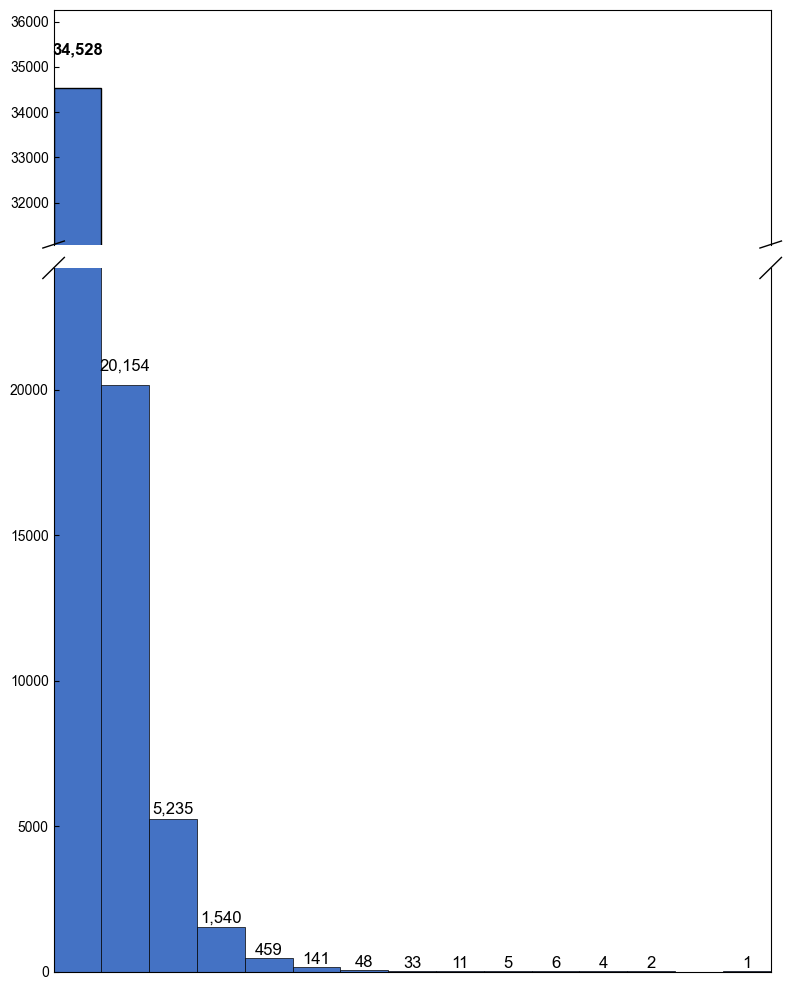

(array([34528, 20154,  5235,  1540,   459,   141,    48,    33,    11,
            5,     6,     4,     2,     0,     1]),
 array([    0.,  1000.,  2000.,  3000.,  4000.,  5000.,  6000.,  7000.,
         8000.,  9000., 10000., 11000., 12000., 13000., 14000., 15000.]))

In [127]:
file_name = "protein_degree_dist-2"
saving_dir = P.Path("/data0/shaojiangyi/pprogo-flg-1/notebooks/figures")
saving_lst = [
    saving_dir / f"{file_name}.png",
    saving_dir / f"{file_name}.svg",
]
plot_degree_distribution_broken(prot_degree, bins=15, saving_path=saving_lst)

In [ ]:
# def plot_degree_pie(node_degree: dict, title=None):
#     """
#     Plot a pie chart of zero-degree vs nonzero-degree nodes.
#     """

#     degrees = np.array(list(node_degree.values()), dtype=int)
#     zero_count = np.sum(degrees == 0)
#     nonzero_count = np.sum(degrees > 0)
#     total = zero_count + nonzero_count

#     labels = [f"Degree = 0 ({zero_count:,})",
#               f"Degree > 0 ({nonzero_count:,})"]
#     sizes = [zero_count, nonzero_count]
#     colors = ["#a6cee3", "#1f78b4"]

#     fig, ax = plt.subplots(figsize=(5, 5))
#     wedges, texts, autotexts = ax.pie(
#         sizes,
#         labels=labels,
#         autopct=lambda p: f"{p:.1f}%\n({int(p*total/100):,})",
#         startangle=90,
#         colors=colors,
#         textprops={'fontsize': 10}
#     )

#     ax.axis("equal")  # equal aspect ratio
#     plt.title(title or "Proportion of Zero-Degree vs Connected Proteins")
#     plt.show()

#     return zero_count, nonzero_count

In [37]:
def plot_degree_bins_pie(node_degree: dict, 
                         bins=[0, 1, 5, 20, 100, np.inf], 
                         title=None,
                         saving_path=None):
    degrees = np.array(list(node_degree.values()))
    # bin_labels = ["=0", "1–4", "5–19", "20–99", "≥100"]
    bin_labels = []
    for i in range(len(bins)-1):
        if bins[i] == 0 and bins[i+1] == 1:
            bin_labels.append("=0")
        elif bins[i+1] == np.inf:
            bin_labels.append(f"≥{int(bins[i])}")
        else:
            bin_labels.append(f"{int(bins[i])}–{int(bins[i+1]-1)}")
    
    counts = [np.sum((degrees >= bins[i]) & (degrees < bins[i+1])) for i in range(len(bins)-1)]

    # colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(counts)))
    colors = plt.colormaps.get_cmap("GnBu")(np.linspace(0.3, 0.9, len(counts)))
    # colors = plt.colormaps.get_cmap("YlGnBu")(np.linspace(0.3, 0.9, len(counts)))

    fig, ax = plt.subplots(figsize=(6, 6))
    wedges, texts, autotexts = ax.pie(
        counts,
        labels=[f"{l} ({c:,})" for l, c in zip(bin_labels, counts)],
        autopct=lambda p: f"{p:.1f}%",
        startangle=90,
        colors=colors,
        textprops={'fontsize': 10}
    )
    ax.axis('equal')
    # plt.title(title or "Protein Degree Distribution (Grouped)")
    plt.show()

    # --- save figure if path provided ---
    if isinstance(saving_path, list):
        # multiple saving path
        # check the surfix
        assert all(isinstance(p, str) or isinstance(p, P.Path)
                   for p in saving_path), "All saving paths must be strings or Path objects"
        for i in range(len(saving_path)):
            p = saving_path[i]
            if isinstance(p, str):
                saving_path[i] = P.Path(p)

    elif isinstance(saving_path, (str, P.Path)):
        if isinstance(saving_path, str):
            saving_path = P.Path(saving_path)
        saving_path = [saving_path]
    else:
        pass
    
    if isinstance(saving_path, list): 
        for p in saving_path:
            assert isinstance(p, P.Path) and \
                 p.suffix in [".png", ".pdf", ".svg"], \
                    "Unsupported file format. Use .png, .pdf, or .svg"
            match p.suffix:
                case ".png":
                    fig.savefig(p, dpi=300, bbox_inches='tight')
                case ".pdf":
                    fig.savefig(p)
                case ".svg":
                    fig.savefig(p, bbox_inches='tight')

    return counts

In [ ]:
# def plot_degree_pie_auto(node_degree: dict,
#                          bins=10,
#                          title=None,
#                          donut=True,
#                          cmap="Blues"):
#     """
#     Automatically bin degrees like the histogram and plot a pie or donut chart.

#     Parameters
#     ----------
#     node_degree : dict
#         {protein_id: degree}
#     bins : int or sequence
#         Number of bins or custom bin edges (same as histogram).
#     title : str
#         Optional chart title.
#     donut : bool
#         If True, draw a donut (pie with a hole in the middle).
#     cmap : str
#         Matplotlib colormap for slices.
#     """

#     # Convert to numpy
#     degree_values = np.array(list(node_degree.values()), dtype=int)
#     max_degree = degree_values.max()
#     hi = round_up_nice(max_degree)

#     # Use same bin logic as bar plot
#     bins_ary = np.linspace(0, hi, bins + 1) if isinstance(bins, int) else np.asarray(bins)
#     counts, bin_edges = np.histogram(degree_values, bins=bins_ary)

#     # Build readable bin labels
#     bin_labels = []
#     for i in range(len(bin_edges) - 1):
#         left, right = bin_edges[i], bin_edges[i + 1]
#         if left == 0:
#             label = "0–{}".format(int(right))
#         else:
#             label = "{}–{}".format(int(left), int(right))
#         bin_labels.append(label)

#     # Filter out empty bins (optional)
#     mask = counts > 0
#     counts = counts[mask]
#     bin_labels = np.array(bin_labels)[mask]

#     # Generate colors
#     colors = plt.cm.get_cmap(cmap)(np.linspace(0.3, 0.9, len(counts)))

#     # Plot
#     fig, ax = plt.subplots(figsize=(6, 6))
#     wedges, texts, autotexts = ax.pie(
#         counts,
#         labels=[f"{l}\n({c:,})" for l, c in zip(bin_labels, counts)],
#         autopct=lambda p: f"{p:.1f}%",
#         startangle=90,
#         colors=colors,
#         textprops={'fontsize': 9}
#     )

#     # Optional: donut style
#     if donut:
#         centre_circle = plt.Circle((0, 0), 0.50, fc='white')
#         fig.gca().add_artist(centre_circle)

#     # Format
#     ax.axis('equal')
#     plt.title(title or "Protein Degree Distribution (Auto-Binned Pie)")
#     plt.tight_layout()
#     plt.show()

#     return counts, bin_edges

[0, 1, 4, 16, 64, 260, 1000, inf]


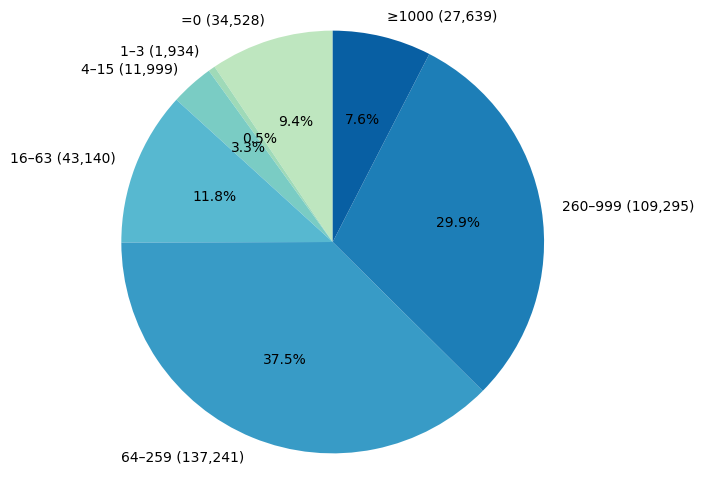

[np.int64(34528),
 np.int64(1934),
 np.int64(11999),
 np.int64(43140),
 np.int64(137241),
 np.int64(109295),
 np.int64(27639)]

In [38]:
# bins=[0, 1, 5, 20, 100, 200, 400, np.inf]
bins = [0] + [round_up_nice(x) for x in np.logspace(0, 3, num=6)] + [np.inf]
print(bins)
file_name = "protein_degree_dist_pie_bins-1"
saving_dir = P.Path("/data0/shaojiangyi/pprogo-flg-1/notebooks/figures")
saving_lst = [
    saving_dir / f"{file_name}.png",
    saving_dir / f"{file_name}.svg",
]
plot_degree_bins_pie(prot_degree, bins=bins, saving_path=saving_lst)